In [ ]:
import mysql.connector
# from sqlalchemy import create_engine, text

import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
# user = 'root'
# password = 'home@123'
# host = 'localhost'
# port = 3306
# database = 'sales_db'

# # Create SQLAlchemy engine
# engine = create_engine(f"mysql+pymysql://{user}:{password}@{host}:{port}/{database}")
# conn = engine.connect()

In [ ]:
# Connect to Mysql Database

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="home@123",
    database="sales_data"
)

cursor = conn.cursor()


In [ ]:
# create_table_sql = """
# CREATE TABLE IF NOT EXISTS sales (
#     id INT AUTO_INCREMENT PRIMARY KEY,
#     product VARCHAR(50),
#     quantity INT,
#     price DECIMAL(10,2)
# )
# """
# conn.execute(text(create_table_sql))

In [ ]:
# Create Table (if not exists)
cursor.execute('''
CREATE TABLE IF NOT EXISTS sales (
    id INT AUTO_INCREMENT PRIMARY KEY,
    product VARCHAR(50),
    quantity INT,
    price DECIMAL(10,2)
)
''')
conn.commit()


In [ ]:
# result = conn.execute(text("SELECT COUNT(*) FROM sales"))
# if result.scalar() == 0:
#     insert_sql = """
#     INSERT INTO sales (product, quantity, price) VALUES
#     ('Apple', 10, 0.5),
#     ('Banana', 5, 0.3),
#     ('Orange', 8, 0.7),
#     ('Apple', 7, 0.5),
#     ('Banana', 10, 0.3)
#     """
#     conn.execute(text(insert_sql))
#     conn.commit()

In [ ]:
#insert sample data
cursor.execute("SELECT COUNT(*) FROM sales")
if cursor.fetchone()[0] == 0:
    sample_data = [
        ("Apple", 10, 0.5),
        ("Banana", 5, 0.3),
        ("Orange", 8, 0.7),
        ("Apple", 7, 0.5),
        ("Banana", 10, 0.3),
    ]
    cursor.executemany("INSERT INTO sales (product, quantity, price) VALUES (%s, %s, %s)", sample_data)
    conn.commit()


In [ ]:
# query = """
# SELECT 
#     product, 
#     SUM(quantity) AS total_qty, 
#     SUM(quantity * price) AS revenue 
# FROM sales 
# GROUP BY product
# """
# df = pd.read_sql_query(query, conn)

In [ ]:
# run SQL Query and Load into pandas
query = """
SELECT 
    product, 
    SUM(quantity) AS total_qty, 
    SUM(quantity * price) AS revenue 
FROM sales 
GROUP BY product
"""
df = pd.read_sql(query, conn)

C:\Users\Home\AppData\Local\Temp\ipykernel_29180\1944033423.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


In [ ]:
print("Sales Summary:")
print(df)

Sales Summary:
  product  total_qty  revenue
0   Apple       17.0      8.5
1  Banana       15.0      4.5
2  Orange        8.0      5.6


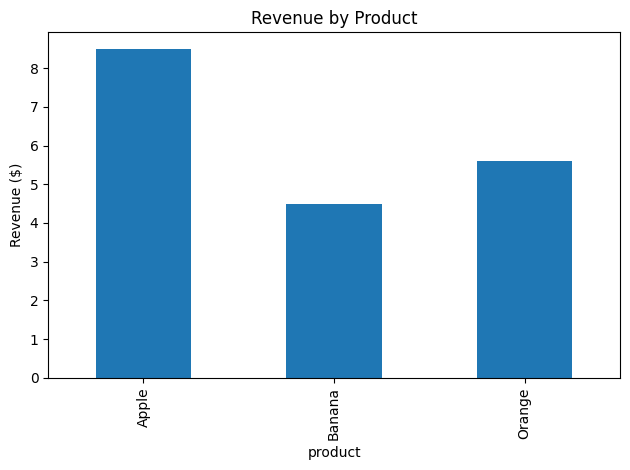

In [ ]:

#Plot Bar Chart
df.plot(kind='bar', x='product', y='revenue', legend=False, title='Revenue by Product')
plt.ylabel('Revenue ($)')
plt.tight_layout()
plt.savefig("sales_chart.png")
plt.show()

In [ ]:
#Close connection
cursor.close()
conn.close()

In [ ]:
# conn.close()
